## Atividade Avaliativa 1.2 - _Churn Prediction_

- Redes Neurais Artificiais 2026.2
- Profa. Elloá B. Guedes (ebgcosta@uea.edu.br)
- http://github.com/elloa

### Equipe

- João Victor Mattos Lopes (github.com/Jaum36)
- Gabriel Augusto da Eira Corrêa Benayon (github.com/devgabrielbenayon)

### Recomendação Importante

A realização desse exercício deve ser feita em duplas de de forma livre durante as aulas, com acompanhamento da professora, utilizando a linguagem Python no ambiente Google Colab. A versão final deve ser depositada no Google Classroom na data estabelecida para a atividade. Os alunos podem consultar a documentação de todos os pacotes recomendados, livros, materiais de apoio e afins. Dissuade-se definitivamente o uso de IA Generativa para a elaboração de respostas, análise e síntese de hípoteses, bem como para a geração automática de código. A entrega dessa atividade contemplará apenas 10% da avaliação do Projeto Prático 1.2. Os 90% restantes da nota serão aferidos por meio de uma prova escrita individual, sem consulta, sobre os elementos contidos decorrentes do desenvolvimento do projeto, cujo conhecimento será de domínio daqueles estudantes que tiverem se empenhado na realização da tarefa.

### Apresentação

A previsão de evasão de clientes (_Churn Prediction_) é um problema tipicamente abordado pela Ciência de Dados com o uso de modelos de _Machine Learning_ para identificar clientes com alta probabilidade de descontinuar o uso de um serviço ou produto. Possui extrema importância para o domínio de negócios, especialmente para empresas com modelos de receita baseados em assinatura (SaaS, telecomunicações, serviços de streaming) ou que dependem da fidelidade do cliente, especialmente por:

1. **Impacto na Receita e Lucratividade.** O custo de adquirir um novo cliente é, em geral, significativamente maior do que o custo de reter um cliente existente. A evasão de clientes (churn) representa uma perda direta de receita recorrente. Ao prever quais clientes estão em risco, as empresas podem intervir com estratégias de retenção direcionadas, como ofertas especiais ou suporte aprimorado, minimizando essa perda financeira. A retenção de clientes não só protege a receita atual, mas também contribui para o aumento do _Lifetime Value_ do cliente, que é a receita total que um cliente gera ao longo de sua relação com a empresa;
2. **Otimização de Recursos e Estratégias.** Sem um modelo de previsão, as empresas tendem a adotar estratégias de retenção de forma genérica, aplicando os mesmos esforços a todos os clientes, independentemente do risco de evasão. Isso leva a um desperdício de recursos;
3. **Entendimento do Comportamento do Cliente.** A construção de um modelo de previsão de churn exige a análise aprofundada dos dados de comportamento do cliente. Esse processo revela insights valiosos sobre o que leva os clientes a ficarem ou a saírem, o que não apenas ajuda a reter clientes, mas também auxilia o desenvolvimento de produtos, a melhoria do serviço e a criação de estratégias de marketing mais eficazes para atrair clientes com um perfil de maior lealdade.

### Contexto do Problema

O termo _Telco_ se refere a _telecommunications industry_. Este domínio é particularmente relevante para a análise de churn devido ao seu alto nível de competição e saturação. Os clientes neste setor — seja para serviços de telefonia móvel, internet ou TV a cabo — têm uma vasta gama de provedores à sua escolha, o que torna relativamente fácil para eles migrarem caso estejam insatisfeitos ou encontrem uma oferta melhor.

### Base de Dados

Base de dados original: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

### Bibliotecas

Por hábito, a primeira célula do notebook costuma ser reservada para importação de bibliotecas.
A cada biblioteca nova acrescida, é necessário executar a célula para atualização e correta execução.

In [1]:
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
import random
import math

## Parte 1 - Análise e Exploração de Dados

### Abertura do Dataset
Abra o dataset e visualize o seu cabeçalho, isto é, os primeiros exemplos nele contidos. Isto é útil para checar se a importação foi realizada de maneira adequada e se a disposição dos dados está de acordo para os próximos passos do trabalho.

In [2]:
df = pd.read_csv("./WA_Fn-UseC_-Telco-Customer-Churn.csv")
header = list(df.columns)
print(header)
print(f"\n{df.info()}")

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBacku

### Conhecendo o dataset

Para praticar conceitos relativos à exploração do conjunto de dados, utilize as células a seguir para prover respostas para cada uma das respostas elencadas

#### Quantos exemplos há no dataset?

In [3]:
examples = df.shape[0]
print(examples)

7043


#### Dados Faltantes

- Elimine todas as entradas em que há dados faltantes
- Qual o decréscimo percentual no tamanho do dataset?

In [4]:
df = df.replace(r'^\s*$', pd.NA, regex=True)
examplesBefore = df.shape[0]
df = df.dropna()
newExamples = df.shape[0]
print(newExamples)

7032


In [5]:
x = (100*newExamples)/examplesBefore
decrescimo = 100 - x
print(f"O decrescimo é de {decrescimo}%")

O decrescimo é de 0.15618344455488398%


#### Dados Duplicados

- Verifique se há clientes duplicados (mesmo id é repetido)
- Em caso afirmativo, elimine as duplicatas, favorecendo as entradas mais recentes

In [6]:
print(df["customerID"].duplicated().any())

False


#### Quais os atributos existentes no dataset e seu tipo?

- Exemplos de tipos de dados são categóricos (nominal ou ordinal), numéricos (discreto ou contínuo), textual ou estampa de tempo. Faça uma análise e agrupe por categoria na sua resposta. Observe que analisar os tipos das variáveis não é suficiente.

- **Categóricos nominais:** gender, SeniorCitizen, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, PaperlessBilling, PaymentMethod, Churn
- **Categórico ordinal:** Contract
- **Númerico Discreto:** tenure
- **Númerico Contínuo:** MonthlyCharges, TotalCharges
- **Textual:** customerID
- **TimeStamp:** Não identificado

#### Qual cliente paga o maior valor de assinatura mensal e que não faz streaming de filmes?

- Apresente o valor pago mensalmente e os demais atributos desse cliente

In [7]:
noStreamingMovies = df[df['StreamingMovies'] == 'No']
filtro1 = noStreamingMovies['MonthlyCharges'] == noStreamingMovies['MonthlyCharges'].max()
print(noStreamingMovies[filtro1])

      customerID gender  SeniorCitizen Partner Dependents  tenure  \
5544  9572-MTILT   Male              0     Yes         No      59   

     PhoneService MultipleLines InternetService OnlineSecurity  ...  \
5544          Yes           Yes     Fiber optic            Yes  ...   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
5544              Yes         Yes         Yes              No  Month-to-month   

     PaperlessBilling     PaymentMethod MonthlyCharges  TotalCharges Churn  
5544              Yes  Electronic check         106.75        6252.9   Yes  

[1 rows x 21 columns]


#### Histograma do tempo de permanência

O histograma é um gráfico que mostra as frequências de uma determinada informação. No nosso caso, vamos construir histogramas que mostram o tempo de permanência no serviço (tenure). Vamos agrupar os valores em bins, cujo número deve ser definido pela Regra de Sturges. 

- Plote dois histogramas, um para os clientes que evadiram do serviço e outro para os que continuaram sua assinatura
- Rotule os eixos e utilize boas práticas de visualização da informação
- Faça a seguinte análise: as distribuições são diferentes?

Documentação completa disponível em: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html


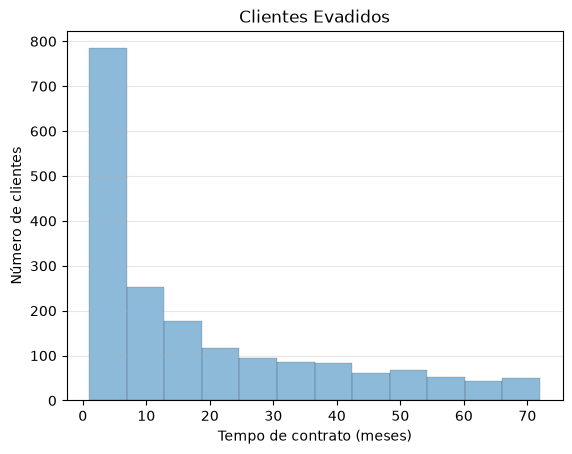

In [8]:
clientesEvadidos = df[df['Churn'] == 'Yes']
binsEvadidos = round(1 + math.log2(len(clientesEvadidos)))

plt.hist(clientesEvadidos['tenure'], bins=binsEvadidos, alpha=0.5, label='Evadidos', edgecolor='black', linewidth=0.2)
plt.xlabel('Tempo de contrato (meses)')
plt.ylabel('Número de clientes')
plt.title('Clientes Evadidos')
plt.grid(axis='y', alpha=0.3)

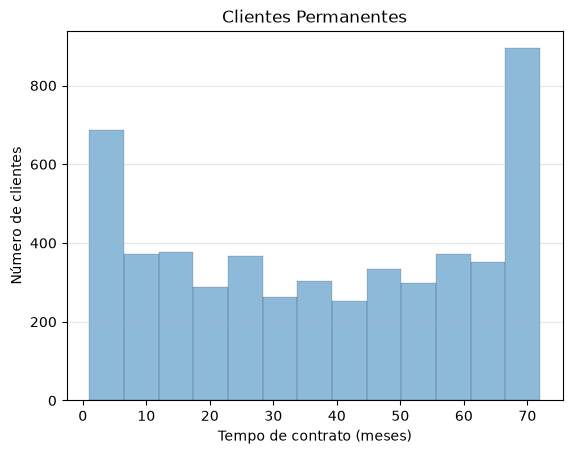

In [9]:
clientesPermanentes = df[df['Churn'] == 'No']
binsPermanentes = round(1 + math.log2(len(clientesPermanentes)))

plt.hist(clientesPermanentes['tenure'], bins=binsPermanentes, alpha=0.5, label='Permanentes', edgecolor='black', linewidth=0.2)
plt.xlabel('Tempo de contrato (meses)')
plt.ylabel('Número de clientes')
plt.title('Clientes Permanentes')
plt.grid(axis='y', alpha=0.3)

São diferentes. A distribuição de tenure dos clientes evadidos é concentrada em valores baixos, com mediana de 10 meses e 75% dos casos com até 29 meses de contrato ou seja, o churn é mais comum logo nos primeiros meses de relacionamento com a empresa. Já a distribuição dos clientes que permaneceram é mais espalhada e deslocada para a direita, com mediana de 38 meses e metade dos clientes concentrados entre 15 e 61 meses. Esse contraste indica que o tempo de permanência é um forte indicador de risco de evasão: quanto mais recente o cliente, maior a probabilidade de churn.


#### Boxplot das Cobranças Mensais

Como é a distribuição das cobranças mensais? O gráfico boxplot pode nos ajudar nesta questão.

O boxplot ilustra informações importantes:
- Mediana
- Limite inferior (menor valor)
- Limite superior (maior valor)
- Q1 (primeiro quartil, 25% dos dados)
- Q3 (terceiro quartil, 75% dos dados)
- Outliers (se houver)

A distribuição dos exemplos no dataset é simétrica no tocante ao atributo em questão? Elabore um parágrafo que justifique as conclusões obtidas a partir da análise do boxplot.

Documentação completa disponível em: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html

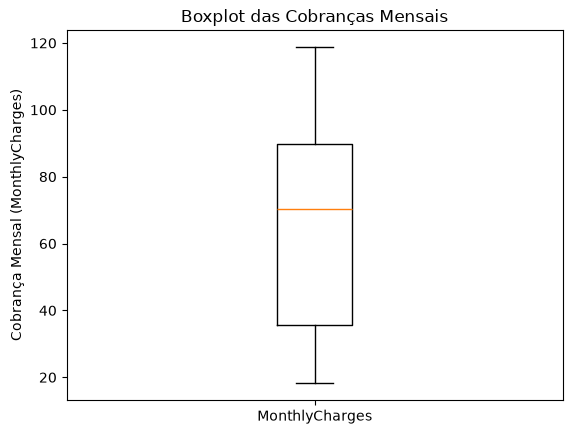

In [10]:
plt.boxplot(df['MonthlyCharges'], orientation='vertical', whis=1.5)

plt.title("Boxplot das Cobranças Mensais")
plt.ylabel("Cobrança Mensal (MonthlyCharges)")
plt.xticks([1], ["MonthlyCharges"])

plt.show()

A distribuição das cobranças mensais não é perfeitamente simétrica. A mediana (70,35) é maior que a média (64,76), e o quartil inferior está mais distante da mediana (Q1 = 35,50) do que o quartil superior (Q3 = 89,85), indicando uma leve assimetria à esquerda (cauda mais longa em direção aos valores baixos). Isso sugere que há um contingente maior de clientes com planos de baixo custo (próximos ao piso de ~18,25) puxando a distribuição para baixo, enquanto a maior parte dos clientes paga valores medianos a altos. Não foram identificados outliers pelo critério de 1.5×IQR, já que os valores mínimo e máximo observados ficam dentro dos limites dos whiskers.


#### Taxa de Churn

- Qual a taxa de churn para cada perfil de tipo de pagamento mensal? Há diferenças?

In [11]:
TaxaChurn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
TaxaChurn.style.format('{:.2f}%')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27%,16.73%
Credit card (automatic),84.75%,15.25%
Electronic check,54.71%,45.29%
Mailed check,80.80%,19.20%


Existe uma diferença considerável, enquanto os clientes que pagam via Electronic check apresentam uma taxa de churn de 45,29%, praticamente o triplo dos demais métodos, os que utilizam pagamento automático (Bank transfer ou Credit card) apresentam as menores taxas, em torno de 15-17%. Mailed check fica em posição intermediária, com 19,11%. Esse padrão sugere que a ausência de automação no pagamento (o cliente precisa agir manualmente todo mês) está associada a uma maior propensão à evasão, possivelmente por refletir um perfil de cliente menos engajado ou mais propenso a interromper o pagamento/assinatura.


#### Avaliação de Hipóteses

Analise as seguintes hipóteses, elaborando gráficos e consulta aos dados para embasar suas justificativas:

- Hipótese 1: "Clientes que optaram por serviços como TechSupport (suporte técnico) têm uma probabilidade menor de churn."
- Hipótese 2: "A taxa de churn é significativamente maior para clientes com contratos de curto prazo em comparação com aqueles com contratos de longo prazo."
- Hipótese 3: "Clientes com múltiplos serviços, com dependentes e que fazem backup online possuem baixa probabilidade de trocar de prestadora"

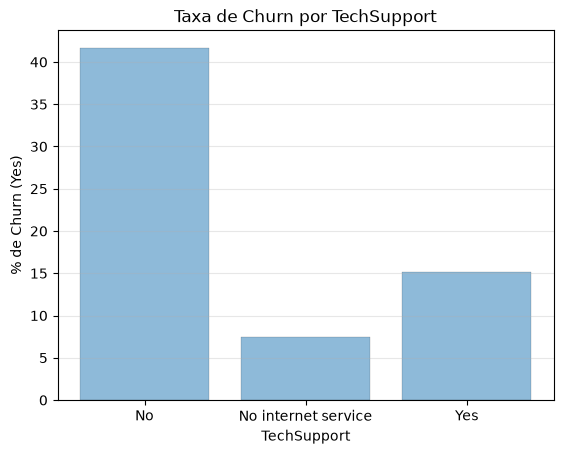

In [12]:
hip1 = pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100
hip1.style.format('{:.2f}%')

plt.bar(hip1.index, hip1['Yes'], alpha=0.5, edgecolor='black', linewidth=0.2)
plt.xlabel('TechSupport')
plt.ylabel('% de Churn (Yes)')
plt.title('Taxa de Churn por TechSupport')
plt.grid(axis='y', alpha=0.3)

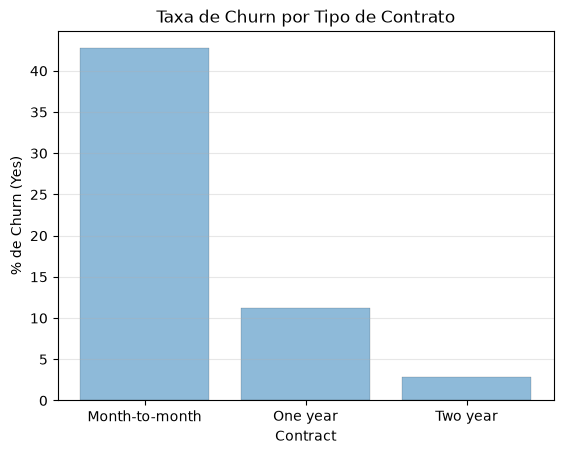

In [13]:
hip2 = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
hip2.style.format('{:.2f}%')

plt.bar(hip2.index, hip2['Yes'], alpha=0.5, edgecolor='black', linewidth=0.2)
plt.xlabel('Contract')
plt.ylabel('% de Churn (Yes)')
plt.title('Taxa de Churn por Tipo de Contrato')
plt.grid(axis='y', alpha=0.3)

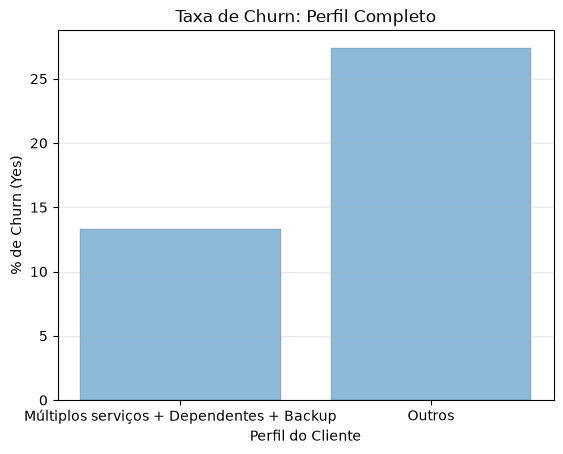

In [14]:
perfilCompleto = (
    (df['MultipleLines'] == 'Yes') &
    (df['Dependents'] == 'Yes') &
    (df['OnlineBackup'] == 'Yes')
)

df['PerfilHip3'] = perfilCompleto.map({True: 'Múltiplos serviços + Dependentes + Backup', False: 'Outros'})

hip3 = pd.crosstab(df['PerfilHip3'], df['Churn'], normalize='index') * 100
hip3.style.format('{:.2f}%')

plt.bar(hip3.index, hip3['Yes'], alpha=0.5, edgecolor='black', linewidth=0.2)
plt.xlabel('Perfil do Cliente')
plt.ylabel('% de Churn (Yes)')
plt.title('Taxa de Churn: Perfil Completo')
plt.grid(axis='y', alpha=0.3)

df = df.drop(columns=['PerfilHip3'])

Hipótese 1: A hipótese é confirmada pelos dados. Clientes sem TechSupport apresentam churn de 41,64%, quase três vezes maior que os que possuem o serviço (15,17%). Já os clientes sem serviço de internet (e, portanto, sem TechSupport aplicável) têm a menor taxa (7,40%), o que reforça que a ausência de suporte técnico entre usuários de internet está associada a maior evasão, possivelmente por frustração com problemas técnicos não resolvidos.

Hipótese 2: A taxa de churn cai de forma acentuada conforme o prazo do contrato aumenta: 42,71% para contratos mensais, 11,27% para contratos anuais e apenas 2,83% para contratos de dois anos. Isso indica que contratos de curto prazo (mês a mês) oferecem menor barreira de saída ao cliente, favorecendo a evasão, enquanto contratos longos criam maior comprometimento e reduzem drasticamente o churn. Logo, a hipótese é fortemente confirmada. 

Hipótese 3: A hipótese é confirmada, ainda que o efeito seja mais moderado que nas hipóteses anteriores. Clientes com o perfil completo (múltiplas linhas, dependentes e backup online) apresentam churn de 13,27%, cerca da metade da taxa observada nos demais clientes (27,35%). Isso sugere que um maior engajamento com a operadora (mais serviços contratados) e vínculos familiares (dependentes) estão associados a uma menor propensão a trocar de prestadora, embora esse grupo represente uma parcela pequena da base (apenas 407 de 7043 clientes).


#### Perfil do Cliente de Risco

Crie uma série de 3 a 4 gráficos conectados que, juntos, respondam à seguinte pergunta:

_**Qual é o perfil do cliente com alta probabilidade de churn e o que mais o influencia a sair?**_

1. Visualização da Distribuição de Permanência (Tenure)  
- Gráfico: Histograma ou gráfico de densidade comparando o tempo de permanência (tenure) de clientes que saíram (Churn = Yes) com o de clientes que ficaram (Churn = No).
- Objetivo: Mostrar visualmente se o churn é mais comum entre clientes novos ou antigos.

2. Análise da Relação entre Tipo de Contrato e Evasão
- Gráfico: Gráfico de barras agrupadas ou empilhadas que mostre a taxa de churn para cada tipo de contrato (Monthly, One year, Two year).
- Objetivo: Demonstrar o impacto do tipo de contrato na decisão do cliente de sair.

3. Combinação de Variáveis: Preços e Serviços
- Gráfico: Gráfico de dispersão (scatter plot) ou um gráfico de box plot que combine duas variáveis-chave, como MonthlyCharges (cobranças mensais) e o tipo de serviço de internet (InternetService), segmentado pela variável Churn.
- Objetivo: Revelar se clientes que pagam mais por um tipo específico de serviço (ex: Fibra Óptica) têm uma taxa de churn diferente. Isso pode sugerir, por exemplo, que a insatisfação está ligada à qualidade de um serviço mais caro.


Escreva um breve parágrafo resumindo as descobertas. A resposta deve conectar as visualizações, respondendo à pergunta inicial sobre o perfil do cliente em risco de forma coesa e baseada nas evidências visuais.

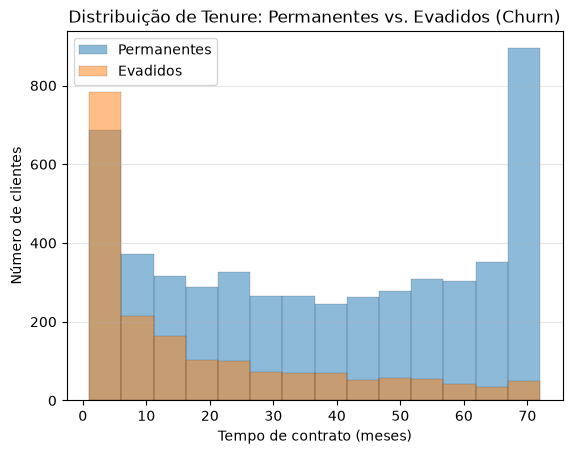

In [15]:
clientesPermanentes = df[df['Churn'] == 'No']
clientesEvadidos = df[df['Churn'] == 'Yes']
binsCombinado = round(1 + math.log2(len(df)))

plt.hist(clientesPermanentes['tenure'], bins=binsCombinado, alpha=0.5, label='Permanentes', edgecolor='black', linewidth=0.2)
plt.hist(clientesEvadidos['tenure'], bins=binsCombinado, alpha=0.5, label='Evadidos', edgecolor='black', linewidth=0.2)

plt.xlabel('Tempo de contrato (meses)')
plt.ylabel('Número de clientes')
plt.title('Distribuição de Tenure: Permanentes vs. Evadidos (Churn)')
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.show()

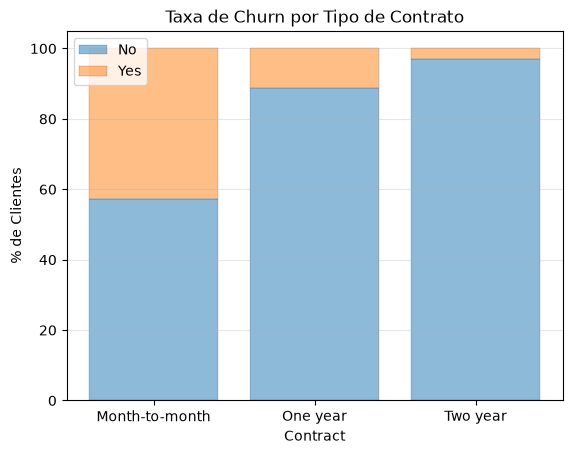

In [16]:
taxaContrato = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

plt.bar(taxaContrato.index, taxaContrato['No'], alpha=0.5, edgecolor='black', linewidth=0.2, label='No')
plt.bar(taxaContrato.index, taxaContrato['Yes'], bottom=taxaContrato['No'], alpha=0.5, edgecolor='black', linewidth=0.2, label='Yes')

plt.xlabel('Contract')
plt.ylabel('% de Clientes')
plt.title('Taxa de Churn por Tipo de Contrato')
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.show()

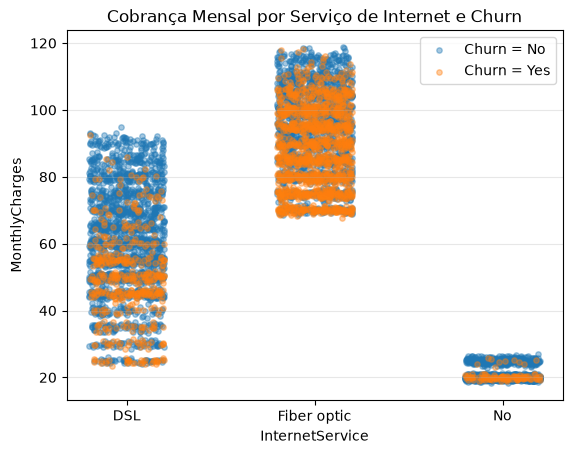

In [17]:
categorias = df['InternetService'].unique()
mapaPosicao = {cat: i for i, cat in enumerate(categorias)}
jitter = 0.2

for churnVal in df['Churn'].unique():
    subset = df[df['Churn'] == churnVal]
    x = [mapaPosicao[cat] + random.uniform(-jitter, jitter) for cat in subset['InternetService']]
    y = subset['MonthlyCharges']
    plt.scatter(x, y, alpha=0.4, s=15, label=f'Churn = {churnVal}')

plt.xticks(list(mapaPosicao.values()), list(mapaPosicao.keys()))
plt.xlabel('InternetService')
plt.ylabel('MonthlyCharges')
plt.title('Cobrança Mensal por Serviço de Internet e Churn')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

O perfil de cliente com alta probabilidade de churn que emerge da análise combina três características centrais: é um cliente recente, com contrato flexível e pagando um valor mensal elevado por internet via Fibra Óptica. O histograma de tenure mostra que a evasão se concentra fortemente nos primeiros meses (mediana de 10 meses entre os evadidos, contra 38 meses entre os que permanecem), indicando que o período inicial é crítico para a retenção.

O gráfico de barras por tipo de contrato reforça essa fragilidade: contratos mensais, que não impõem barreira de saída, têm taxa de churn de 42,71%, quase 4 vezes maior que contratos anuais (11,27%) e 15 vezes maior que contratos de dois anos (2,83%). 

Por fim, o gráfico de dispersão de cobranças mensais por tipo de serviço de internet revela que os assinantes de Fibra Óptica, o serviço mais caro do portfólio, apresentam a maior taxa de churn entre os tipos de internet (41,89%, contra 18,96% do DSL). Em conjunto, essas evidências sugerem que o cliente de risco é aquele que ainda não desenvolveu vínculo de longo prazo com a empresa (baixo tenure, sem contrato de fidelidade) e que percebe um alto custo-benefício negativo no serviço premium de Fibra Óptica, sendo, portanto, mais sensível a ofertas concorrentes ou a problemas de qualidade percebida frente ao preço pago.

#### Gênero do Cliente

Conforme a documentação da base de dados, há dois valores possíveis para o gênero do cliente, são eles:  
    - M: Masculino  
    - F: Feminino  
    
Tal como dispostos, segundo strings, essas informações não ajudam modelos que lidam apenas com dados numéricos. É necessário efetuar uma codificação para representar tais valores. Assim, codifique a coluna gender conforme a abordagem One-Hot Encoding e elimine a coluna original do dataset.

Referências:
- https://towardsdatascience.com/what-is-one-hot-encoding-and-how-to-use-pandas-get-dummies-function-922eb9bd4970
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

In [18]:
df = pd.get_dummies(df, columns=['gender'], drop_first=False)

#### Codificação dos Atributos

- Se o atributo tiver de duas até cinco categorias, repita o processo de codificação conforme proposto anteriormente. 
- Em caso contrário, elimine a coluna em questão. Essa é uma prática utilizada no escopo deste exercício, em situações reais faz-se One-Hot Encoding mantendo-se um alto número de colunas mesmo assim

- A alternativa para o One-Hot Encoding é o Label Encoding. Quais são as críticas a essa forma de codificação?

Referências:
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html


In [19]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

colunasCategoricas = df.select_dtypes(include=['object', 'str']).columns
colunasCategoricas = colunasCategoricas.drop('Churn')

for col in colunasCategoricas:
    nCategorias = df[col].nunique()
    if 2 <= nCategorias <= 5:
        df = pd.get_dummies(df, columns=[col], drop_first=False)
    else:
        df = df.drop(columns=[col])

A principal crítica ao Label Encoding é que ele atribui números inteiros arbitrários e sequenciais (0, 1, 2, ...) às categorias, criando uma relação de ordem e distância entre elas que, na maioria das vezes, não existe no atributo original. Para variáveis nominais (sem ordem natural, como InternetService ou PaymentMethod), isso induz o modelo a interpretar erroneamente que uma categoria é "maior", "mais próxima" ou "mais importante" que outra apenas pelo valor numérico atribuído, o que é enganoso e pode prejudicar o desempenho de modelos sensíveis a relações de magnitude e distância, como Regressão Logística, KNN e redes neurais. 

O One-Hot Encoding evita esse problema ao representar cada categoria como uma dimensão binária independente, sem impor ordem artificial, ao custo de aumentar a dimensionalidade dos dados. O Label Encoding só é adequado, sem prejuízo, para atributos categóricos ordinais, em que a ordem numérica de fato reflete uma relação real entre as categorias (por exemplo, Contract: Month-to-month < One year < Two year).


#### O dataset é balanceado?

- Considera-se que o dataset é balanceado se não houver mais de 10% de diferença no quantitativo das classes nele presentes. Faça a avaliação nesses termos. Elabore gráficos que justificam sua resposta.
- A partir da resposta considerada, apresente quatro métricas de desempenho a serem utilizadas na avaliação comparativa de modelos para esse problema

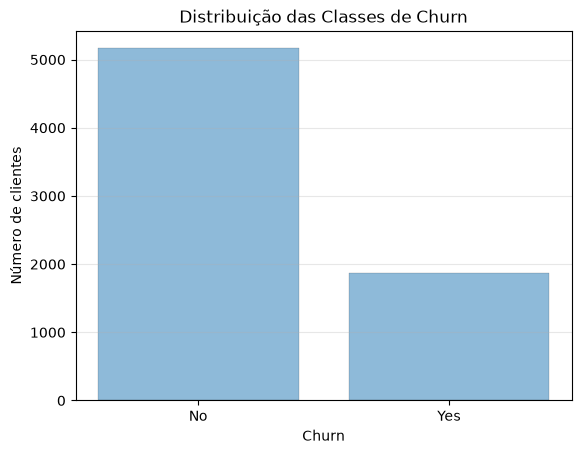

In [20]:
contagemChurn = df['Churn'].value_counts()

plt.bar(contagemChurn.index, contagemChurn.values, alpha=0.5, edgecolor='black', linewidth=0.2)
plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.title('Distribuição das Classes de Churn')
plt.grid(axis='y', alpha=0.3)

plt.show()

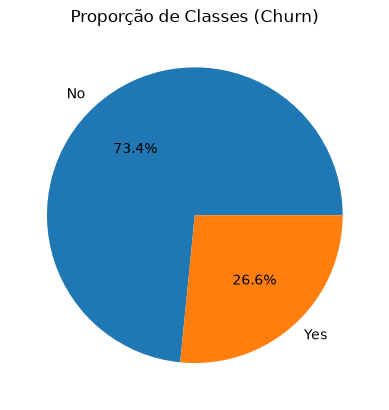

In [21]:
plt.pie(contagemChurn.values, labels=contagemChurn.index, autopct='%1.1f%%')
plt.title('Proporção de Classes (Churn)')
plt.show()

É desbalanceado. A classe "No" (clientes que permaneceram) representa 73,46% do dataset, enquanto a classe "Yes" (evadidos) representa apenas 26,54%, uma diferença de aproximadamente 47 pontos percentuais, muito acima do limite de 10% considerado para caracterizar balanceamento. Isso é evidenciado tanto pelo gráfico de barras quanto pelo gráfico de pizza, que mostram claramente a classe majoritária dominando cerca de três quartos dos exemplos.

Nesse cenário, a acurácia sozinha não é uma métrica confiável, pois um modelo trivial que sempre prevê "No" já atingiria cerca de 73% de acurácia sem aprender nada sobre o problema. Assim, sugerem-se as seguintes métricas para a avaliação comparativa dos modelos:

1. **Precisão (Precision)** — mede a proporção de previsões de churn que estavam corretas, importante para avaliar o custo de ações de retenção desnecessárias em falsos positivos.
2. **Revocação/Sensibilidade (Recall)** — mede a proporção de clientes que realmente evadiram e foram corretamente identificados, crucial neste problema, já que deixar de identificar um cliente em risco (falso negativo) tem alto custo de negócio.
3. **F1-Score** — média harmônica entre precisão e recall, útil para resumir o desempenho em uma única métrica quando há trade-off entre as duas e a classe de interesse é minoritária.
4. **AUC-ROC (ou AUC-PR)** — avalia a capacidade do modelo de discriminar entre as classes em diferentes limiares de decisão, sendo a AUC-PR (Precision-Recall) especialmente recomendada em cenários de forte desbalanceamento, por ser mais sensível ao desempenho na classe minoritária do que a AUC-ROC.


## Parte 2 - Tarefa de Aprendizado de Máquina

Abordaremos o problema da previsão de churn como uma tarefa de classificação binária.

#### Preparação dos dados para Validação Cruzada Holdout

- Vamos separar o atributo alvo (Age) dos atributores preditores. 
  - Atributos preditores devem ser armazenados em uma variável denominada X  
  - Atributo alvo deve ser armazenado em uma variável denominada y
  - Garanta que o atributo alvo não está nos atributos preditores
- Qual o tipo de entrada do modelo?
- Vamos efetuar uma partição do tipo holdout estratificada 70/30
  - Quais as características de uma partição estratificada?

Documentação completa disponível em: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

#### Treinar um modelo de regressão logística para o problema

A Regressão Logística é uma técnica de Aprendizado de Máquina que tem como objetivo produzir, a partir de um conjunto de observações, um modelo que permita a predição de valores tomados por uma variável categórica, frequentemente binária, a partir de uma série de variáveis explicativas.

1. Importe o modelo da biblioteca sklearn
2. Instancie o modelo com parâmetros padrão (default)
3. Execute o algoritmo de treinamento com os dados de treino

Documentação completa disponível em: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

#### Obtendo previsões do modelo

1. Selecione um exemplo arbitrário da partição de teste
2. Forneça os atributos preditores e obtenha a previsão da churn
3. O modelo previu a saída corretamente?

#### Avalie o modelo perante o conjunto de testes

1. Obtenha as métricas elencadas para o conjunto de testes
  * Efetue a importação de tais métricas a partir do pacote sklearn.metrics
2. Elabore uma visualização da matriz de confusão normalizada para as previsões do conjunto de testes
3. O modelo é bom para o problema? Justifique sua afirmação.

#### Treinar um modelo de K-Vizinhos Mais Próximos

É um algoritmo de Aprendizado de Máquina que baseia-se na média dos valores dos k vizinhos mais próximos a uma dada entrada para produzir uma estimativa para o atributo-alvo. É considerado "preguiçoso", mas muito mostra-se vantajoso por possuir um baixo custo computacional.

1. Efetue o treinamento do K-Vizinhos mais Próximos, considerando k = 5
2. Efetue o teste no modelo e obtenha as métricas de desempenho previamente indicadas.  

#### Treinar um modelo de Árvore de Decisão

É um modelo de aprendizado de máquina supervisionado, utilizado para problemas de classificação e regressão. Sua estrutura se assemelha a um fluxograma, em que cada nó interno representa um teste em uma atributo dado, cada ramo corresponde a um resultado desse teste, e cada nó folha a uma decisão final ou previsão. Destaca-se por sua interpretabilidade

1. Efetue o treinamento do Árvore de Decisão, utilizando o critério de entropia.
2. Efetue o teste no modelo e obtenha as métricas de desempenho previamente indicadas.  
3. Plote a árvore de decisão construída.

#### Síntese dos Resultados

- Agrupe as matrizes de confusão obtidas lado a lado
- Crie uma tabela com todos os modelos e métricas (Pretty Table)

#### Argumente

- Qual o melhor modelo para o problema em questão?
- Qual o grau de dificuldade da tarefa de aprendizado proposta? Justifique a partir dos elementos e resultados obtidos nas células anteriores.